# 模型融合与特征贡献（MT-4 特征组）

这个 notebook 接在 `model-training-4` 后面使用，目标是把已经搜索出来的最佳 LightGBM / XGBoost 参数真正用于融合实验，并把每一步结果做成更容易阅读的中文表格和中文图。

## 输入

- 原始数据：`input/creditcard.csv`
- MT-4 配置：`../model-training/model_training_if_log1p_atop2_purgedcv_mt4.json`
- 特征组：`IF + hours_since_start + log1p_amount + A_top2`
- 模型：LightGBM 与 XGBoost，均使用 MT-4 中保存的最佳超参数

## 本 notebook 做什么

1. 重新构造 MT-4 的完整特征组，保证融合实验和 MT-4 使用同一批特征。
2. 用 purged walk-forward 生成 LightGBM / XGBoost 的 OOF 预测，避免融合阶段偷看验证集。
3. 汇总两类模型的特征贡献，先看模型到底主要依赖哪些变量。
4. 分别评估三种融合路线：
   - 权重搜索平均：`w * LightGBM + (1 - w) * XGBoost`
   - Rank average：先把预测分数转成排序百分位，再做平均
   - Logistic Regression stacking：把两个基础模型的 OOF 预测作为二层模型输入
5. 输出中文图表与 CSV / JSON 结果，方便后续写报告或复盘。

## 评价口径

主指标沿用 MT-4：优先看 AUC-PR；阈值类指标通过 OOF 阈值搜索得到，包括 F1、Precision、Recall、FP、FN。

In [54]:
import warnings
warnings.filterwarnings('ignore')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, StandardScaler

import lightgbm as lgb
import xgboost as xgb
from IPython.display import display

from purgedcv import WalkForwardSplit
from purgedcv.diagnostics import assert_no_temporal_leakage

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 140)

# 图表统一使用中文标题和坐标轴；按常见系统字体顺序回退，避免中文乱码。
plt.rcParams['font.sans-serif'] = [
    'Arial Unicode MS', 'Heiti TC', 'STHeiti', 'PingFang SC',
    'SimHei', 'Microsoft YaHei', 'DejaVu Sans',
]
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

MODEL_COLORS = {
    'LightGBM': '#4C78A8',
    'XGBoost': '#F58518',
    'weighted_average_best': '#54A24B',
    'rank_average': '#B279A2',
    'logistic_stacking': '#E45756',
}


def find_project_root(start=None):
    """自动定位项目根目录，保证从项目根目录、src 或当前 notebook 文件夹启动都能读到数据。"""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'input' / 'creditcard.csv').exists():
            return candidate
    raise FileNotFoundError('无法从当前工作目录向上找到 input/creditcard.csv')


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'input' / 'creditcard.csv'
MT4_CONFIG_PATH = PROJECT_ROOT / 'src' / 'model-training' / 'model_training_if_log1p_atop2_purgedcv_mt4.json'
OUTPUT_DIR = PROJECT_ROOT / 'src' / 'model-stacking' / 'output'
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# 以下常量保持和 MT-4 一致，确保融合实验和上一阶段训练协议可比。
EARLY_STOPPING_ROUNDS = 50
MAX_BOOST_ROUNDS = 1500
ES_FRAC = 0.20
CV_N_SPLITS = 5
CV_RANDOM_STATE = 42
IF_RANDOM_STATE = 42
IF_N_ESTIMATORS = 200
IF_MAX_SAMPLES = 0.5
IF_CONTAMINATION = 'auto'
IF_MAX_NORMAL_SAMPLES = 50_000
CV_EMBARGO = pd.Timedelta(hours=2)
CV_PURGE_HORIZON = pd.Timedelta(0)

print('项目根目录:', PROJECT_ROOT)
print('数据路径:', DATA_PATH)
print('MT-4 配置路径:', MT4_CONFIG_PATH)
print('图表输出目录:', FIGURE_DIR)

项目根目录: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets
数据路径: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/input/creditcard.csv
MT-4 配置路径: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-training/model_training_if_log1p_atop2_purgedcv_mt4.json
图表输出目录: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures


In [55]:
def read_creditcard_csv(path: Path) -> pd.DataFrame:
    """按 MT-4 的读取策略尝试多种编码，避免 CSV 编码差异导致读取失败。"""
    for kwargs in (
        {'encoding': 'utf-8'},
        {'encoding': 'utf-8', 'encoding_errors': 'replace'},
        {'encoding': 'latin-1'},
    ):
        try:
            return pd.read_csv(path, **kwargs)
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, 'failed')


def build_eda_features(data: pd.DataFrame) -> pd.DataFrame:
    """补充 MT-4 用到的基础衍生特征。"""
    out = data.copy()
    # 金额通常长尾明显，log1p 能压缩极端大额交易的影响。
    out['log1p_amount'] = np.log1p(out['Amount'])
    # Time 是从数据起点开始累计的秒数，这里转成小时粒度，捕捉日内/时间段差异。
    out['hours_since_start'] = (out['Time'] // 3600).astype(int)
    # MT-4 的 A_top2 交叉特征使用 1 欧元交易作为门控条件。
    out['is_one_euro'] = out['Amount'] == 1.0
    return out


def build_cross_features(data: pd.DataFrame, top_v, gate_col='is_one_euro', prefix='one_euro'):
    """构造 A_top2 交叉特征：只有满足门控条件的交易才激活对应 V 特征。"""
    out = data.copy()
    gate = out[gate_col].astype(float)
    new_cols = []
    for v in top_v:
        name = f'{prefix}_{v}'
        out[name] = gate * out[v]
        new_cols.append(name)
    return out, new_cols


def sort_by_time(data: pd.DataFrame) -> pd.DataFrame:
    return data.sort_values('Time', kind='mergesort').reset_index(drop=True)


_CV_BOUND_DATA = None


def bind_cv_data(data: pd.DataFrame) -> pd.DataFrame:
    global _CV_BOUND_DATA
    out = sort_by_time(data)
    _CV_BOUND_DATA = out
    return out


def build_cv_timestamps(data: pd.DataFrame):
    t = pd.to_timedelta(data['Time'].astype(float), unit='s')
    return t.copy(), t.copy()


def iter_purged_cv_folds(n_samples=None, n_splits=CV_N_SPLITS, data=None):
    """生成 purged walk-forward 折，按时间向前验证，并保留 embargo 防止时间邻近泄漏。"""
    bound = data if data is not None else _CV_BOUND_DATA
    if bound is None:
        raise RuntimeError('请先调用 bind_cv_data() 绑定按时间排序后的数据')
    n = n_samples if n_samples is not None else len(bound)
    pred, evalu = build_cv_timestamps(bound)
    test_size = max(1, n // (n_splits + 1))
    cv = WalkForwardSplit(
        n_splits=n_splits,
        test_size=test_size,
        window='expanding',
        prediction_times=pred,
        evaluation_times=evalu,
        purge_horizon=CV_PURGE_HORIZON,
        embargo=CV_EMBARGO,
    )
    for tr_idx, va_idx in cv.split(np.arange(n)):
        assert_no_temporal_leakage(
            tr_idx,
            va_idx,
            prediction_times=pred,
            evaluation_times=evalu,
            purge_horizon=CV_PURGE_HORIZON,
        )
        yield tr_idx, va_idx


def make_fold_iter(X, y, n_splits=CV_N_SPLITS, random_state=CV_RANDOM_STATE):
    yield from iter_purged_cv_folds(len(X), n_splits=n_splits)


def make_if_fold_iter(data: pd.DataFrame, n_splits=CV_N_SPLITS):
    yield from iter_purged_cv_folds(data=data, n_splits=n_splits)


def split_early_stop_set(X_tr, y_tr, es_frac=ES_FRAC, random_state=CV_RANDOM_STATE):
    return train_test_split(
        X_tr,
        y_tr,
        test_size=es_frac,
        random_state=random_state,
        stratify=y_tr,
    )

In [56]:
WEIGHT_SCHEMES = {
    'balanced': None,
    'spw_sqrt': 'sqrt',
    'spw_0.5x': 0.5,
    'spw_2x': 2.0,
    'no_weight': 0.0,
}


def apply_weight_scheme(defaults, model_name, spw, weight_scheme='balanced'):
    vk = WEIGHT_SCHEMES[weight_scheme]
    defaults.pop('scale_pos_weight', None)
    defaults.pop('class_weight', None)
    if model_name == 'LightGBM':
        if vk is None:
            defaults['class_weight'] = 'balanced'
        elif vk == 0.0:
            pass
        elif vk == 'sqrt':
            defaults['class_weight'] = {0: 1.0, 1: float(np.sqrt(spw))}
        else:
            defaults['class_weight'] = {0: 1.0, 1: spw * vk}
    else:
        if vk is None:
            defaults['scale_pos_weight'] = spw
        elif vk == 0.0:
            defaults['scale_pos_weight'] = 1.0
        elif vk == 'sqrt':
            defaults['scale_pos_weight'] = float(np.sqrt(spw))
        else:
            defaults['scale_pos_weight'] = spw * vk
    return defaults


def make_classifier(model_name, y_train, params=None):
    """构造 LightGBM / XGBoost，并叠加 MT-4 搜索出的最佳超参数。"""
    params = dict(params or {})
    # 欺诈样本极少，用训练折内部的负/正样本比例计算不平衡权重，避免验证集信息泄漏。
    spw = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
    weight_scheme = params.pop('weight_scheme', 'balanced')
    if weight_scheme not in WEIGHT_SCHEMES:
        raise ValueError(f'未知 weight_scheme: {weight_scheme!r}')

    if model_name == 'LightGBM':
        defaults = dict(
            n_estimators=MAX_BOOST_ROUNDS,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=0.1,
            random_state=42,
            verbose=-1,
            n_jobs=-1,
            importance_type='gain',
        )
        defaults.update(params)
        defaults = apply_weight_scheme(defaults, model_name, spw, weight_scheme)
        return lgb.LGBMClassifier(**defaults)

    defaults = dict(
        n_estimators=MAX_BOOST_ROUNDS,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=-1,
        importance_type='gain',
    )
    defaults.update(params)
    defaults['early_stopping_rounds'] = EARLY_STOPPING_ROUNDS
    defaults = apply_weight_scheme(defaults, model_name, spw, weight_scheme)
    return xgb.XGBClassifier(**defaults)


def fit_classifier(clf, model_name, X_tr, y_tr, X_es=None, y_es=None):
    if X_es is None:
        clf.fit(X_tr, y_tr)
        return clf
    if model_name == 'LightGBM':
        clf.fit(
            X_tr,
            y_tr,
            eval_set=[(X_es, y_es)],
            eval_metric='binary_logloss',
            callbacks=[lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False)],
        )
    else:
        clf.fit(X_tr, y_tr, eval_set=[(X_es, y_es)], verbose=False)
    return clf


def oof_if_anomaly_score(data, feature_cols, y_col='Class', n_splits=CV_N_SPLITS, random_state=IF_RANDOM_STATE, fold_iter=None):
    """生成 Isolation Forest 的 OOF 异常分，只在每折训练集的正常样本上拟合。"""
    X = data[feature_cols].values.astype(np.float64)
    y = data[y_col].values
    oof = np.zeros(len(y), dtype=np.float64)
    for fold, (tr_idx, va_idx) in enumerate(fold_iter, start=1):
        normal_tr = tr_idx[y[tr_idx] == 0]
        if len(normal_tr) > IF_MAX_NORMAL_SAMPLES:
            rng = np.random.default_rng(random_state + fold)
            normal_tr = rng.choice(normal_tr, size=IF_MAX_NORMAL_SAMPLES, replace=False)
        scaler = StandardScaler()
        X_n = scaler.fit_transform(X[normal_tr])
        X_va = scaler.transform(X[va_idx])
        iforest = IsolationForest(
            n_estimators=IF_N_ESTIMATORS,
            max_samples=IF_MAX_SAMPLES,
            contamination=IF_CONTAMINATION,
            random_state=random_state + fold,
            n_jobs=-1,
        )
        iforest.fit(X_n)
        oof[va_idx] = -iforest.score_samples(X_va)
        print(f'  IF fold {fold}/{n_splits} done (normal={len(normal_tr):,})')
    return oof

In [57]:
def search_best_threshold(y_true, proba, auc_pr, thresholds=None):
    """在 OOF 预测上搜索 F1 最优阈值，并返回每个阈值下的分类指标。"""
    thresholds = np.linspace(0.01, 0.99, 99) if thresholds is None else np.asarray(thresholds)
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba, dtype=float)
    rows = []

    # 这里手算 TP/FP/FN，而不是反复调用 sklearn 指标函数；权重搜索会调用很多次，手算更快。
    for t in thresholds:
        pred = proba >= t
        tp = int(np.sum(pred & (y_true == 1)))
        fp = int(np.sum(pred & (y_true == 0)))
        fn = int(np.sum((~pred) & (y_true == 1)))
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        rows.append({
            'threshold': float(t),
            'F1': float(f1),
            'Precision': float(precision),
            'Recall': float(recall),
            'FP': fp,
            'FN': fn,
            'AUC-PR': float(auc_pr),
        })

    scan = pd.DataFrame(rows)
    best = scan.loc[scan['F1'].idxmax()].copy()
    return float(best['threshold']), scan, best


def evaluate_prediction(name, y_true, proba, extra=None, return_scan=True):
    """统一评估一个预测向量，并自动排除 walk-forward 中未被验证折覆盖的样本。

    walk-forward 的最前段样本只承担 warm-up 训练窗口角色，本来就没有 OOF 预测。
    因此这些位置会保留为 NaN，评估时必须排除，不能填 0 后参与 AUC-PR。
    """
    y_true = np.asarray(y_true).astype(int)
    proba = np.asarray(proba, dtype=float)
    eval_mask = np.isfinite(proba)
    y_eval = y_true[eval_mask]
    proba_eval = proba[eval_mask]
    if len(y_eval) == 0:
        raise ValueError(f'{name} 没有可评估的 OOF 预测样本')

    auc_pr = average_precision_score(y_eval, proba_eval)
    threshold, threshold_scan, best_threshold_row = search_best_threshold(y_eval, proba_eval, auc_pr)
    row = {
        'method': name,
        'n_eval': int(eval_mask.sum()),
        'n_excluded': int((~eval_mask).sum()),
        'AUC-PR': float(auc_pr),
        'logloss': float(log_loss(y_eval, np.clip(proba_eval, 1e-7, 1 - 1e-7), labels=[0, 1])),
        'best_threshold': threshold,
        'F1': float(best_threshold_row['F1']),
        'Precision': float(best_threshold_row['Precision']),
        'Recall': float(best_threshold_row['Recall']),
        'FP': int(best_threshold_row['FP']),
        'FN': int(best_threshold_row['FN']),
    }
    if extra:
        row.update(extra)
    return row, threshold_scan if return_scan else None


def cross_val_oof_with_importance(model_name, data, feature_cols, params=None, n_splits=CV_N_SPLITS):
    """按 purged walk-forward 生成 OOF 预测，同时记录每折的模型原生 gain 重要性。"""
    X, y = data[feature_cols], data['Class']
    # 用 NaN 表示“没有 OOF 预测”。walk-forward 的 warm-up 训练窗口不会进入验证折，不能用 0 冒充预测值。
    oof = np.full(len(y), np.nan, dtype=float)
    covered = np.zeros(len(y), dtype=bool)
    fold_rows = []
    importance_rows = []

    for fold, (tr_idx, va_idx) in enumerate(make_fold_iter(X, y, n_splits=n_splits), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        # 每个训练折内部再切早停集，避免用验证折指导 boosting 轮数。
        X_fit, X_es, y_fit, y_es = split_early_stop_set(X_tr, y_tr, random_state=CV_RANDOM_STATE + fold)
        clf = make_classifier(model_name, y_fit, params=params)
        fit_classifier(clf, model_name, X_fit, y_fit, X_es, y_es)
        proba = clf.predict_proba(X_va)[:, 1]
        oof[va_idx] = proba
        covered[va_idx] = True

        fold_rows.append({
            'model': model_name,
            'fold': fold,
            'logloss': float(log_loss(y_va, np.clip(proba, 1e-7, 1 - 1e-7), labels=[0, 1])),
            'AUC-PR': float(average_precision_score(y_va, proba)),
            'n_train': int(len(tr_idx)),
            'n_valid': int(len(va_idx)),
        })
        importance_rows.append(pd.DataFrame({
            'model': model_name,
            'fold': fold,
            'feature': feature_cols,
            'importance': np.asarray(clf.feature_importances_, dtype=float),
        }))
        print(f'  {model_name} 第 {fold}/{n_splits} 折：AUC-PR={fold_rows[-1]["AUC-PR"]:.4f}，logloss={fold_rows[-1]["logloss"]:.5f}')

    return oof, pd.DataFrame(fold_rows), pd.concat(importance_rows, ignore_index=True), covered


def summarize_importance(importance_df):
    """把每折重要性聚合成均值、标准差和模型内贡献占比。"""
    out = (
        importance_df.groupby(['model', 'feature'], as_index=False)
        .agg(importance_mean=('importance', 'mean'), importance_std=('importance', 'std'))
    )
    out['importance_share'] = out.groupby('model')['importance_mean'].transform(
        lambda s: s / s.sum() if s.sum() else 0.0
    )
    return out.sort_values(['model', 'importance_mean'], ascending=[True, False])


def rank_percentile(proba):
    """把预测概率转成百分位排名，用于消除不同模型概率尺度差异。"""
    return pd.Series(proba).rank(method='average', pct=True).to_numpy()


def weighted_average_search(y_true, lgb_oof, xgb_oof):
    """搜索 LightGBM / XGBoost 加权平均的最佳权重。"""
    rows = []
    for w_lgb in np.linspace(0.0, 1.0, 101):
        proba = w_lgb * lgb_oof + (1.0 - w_lgb) * xgb_oof
        row, _ = evaluate_prediction(
            'weighted_average',
            y_true,
            proba,
            extra={'w_lgb': float(w_lgb), 'w_xgb': float(1.0 - w_lgb)},
            return_scan=False,
        )
        rows.append(row)

    grid = pd.DataFrame(rows)
    best_idx = grid.sort_values(['AUC-PR', 'F1', 'logloss'], ascending=[False, False, True]).index[0]
    best = grid.loc[best_idx].copy()
    best_proba = best['w_lgb'] * lgb_oof + best['w_xgb'] * xgb_oof
    _, best_scan = evaluate_prediction('weighted_average', y_true, best_proba, return_scan=True)
    return best, grid, best_scan


def stacking_oof(meta_features, y, n_splits=CV_N_SPLITS):
    """用基础模型 OOF 预测训练二层逻辑回归，并继续输出二层 OOF 预测。

    注意：二层模型的输入本身也是 OOF 预测，所以 warm-up 区间没有基础模型预测。
    每个 meta fold 训练时只使用已经有基础模型 OOF 预测的训练样本；没有足够训练样本的早期 fold 会跳过。
    二层线性模型前使用 RobustScaler，降低极端概率值对缩放参数的影响；这里不做 logit 变换。
    逻辑回归使用 L2 正则，缓解两个基础模型 OOF 预测高度相关时的系数不稳定问题。
    """
    meta_features = pd.DataFrame(meta_features).reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    meta_covered = meta_features.notna().all(axis=1).to_numpy()
    oof = np.full(len(y), np.nan, dtype=float)
    coef_rows = []

    for fold, (tr_idx, va_idx) in enumerate(make_fold_iter(meta_features, y, n_splits=n_splits), start=1):
        tr_idx = np.asarray(tr_idx)
        va_idx = np.asarray(va_idx)
        tr_idx_meta = tr_idx[meta_covered[tr_idx]]
        va_idx_meta = va_idx[meta_covered[va_idx]]
        if len(tr_idx_meta) == 0 or len(va_idx_meta) == 0:
            print(f'  Stacking 第 {fold}/{n_splits} 折跳过：训练或验证样本没有基础模型 OOF 预测')
            continue

        # RobustScaler 使用中位数和 IQR 缩放，比 StandardScaler 更不容易被极端预测概率影响。
        scaler = RobustScaler()
        X_tr = scaler.fit_transform(meta_features.iloc[tr_idx_meta])
        X_va = scaler.transform(meta_features.iloc[va_idx_meta])
        # 使用 L2 正则抑制共线性带来的系数漂移；C 越小正则越强，这里先用 sklearn 默认强度 C=1.0。
        clf = LogisticRegression(
            penalty='l2',
            C=1.0,
            solver='lbfgs',
            max_iter=1000,
            class_weight='balanced',
            random_state=CV_RANDOM_STATE + fold,
        )
        clf.fit(X_tr, y.iloc[tr_idx_meta])
        oof[va_idx_meta] = clf.predict_proba(X_va)[:, 1]
        coef_rows.append(pd.DataFrame({
            'fold': fold,
            'meta_feature': meta_features.columns,
            'coef': clf.coef_[0],
        }))
        print(f'  Stacking 第 {fold}/{n_splits} 折完成（meta 训练样本={len(tr_idx_meta):,}，验证样本={len(va_idx_meta):,}）')

    if not coef_rows:
        raise ValueError('Stacking 没有任何可训练折，请检查基础模型 OOF 覆盖范围')
    return oof, pd.concat(coef_rows, ignore_index=True)

In [58]:
METHOD_NAME_ZH = {
    'LightGBM': 'LightGBM 单模型',
    'XGBoost': 'XGBoost 单模型',
    'weighted_average_best': '最优加权平均',
    'rank_average': '排序平均',
    'logistic_stacking': '逻辑回归 Stacking',
}

METRIC_NAME_ZH = {
    'AUC-PR': 'covered OOF AUC-PR',
    'AUC-PR_fold_mean': '分折 AUC-PR 均值',
    'F1': 'F1 分数',
    'Precision': 'Precision（精确率）',
    'Recall': 'Recall（召回率）',
    'logloss': 'Logloss',
}


def method_name_zh(name):
    """把代码里的方法名转换成图表中更易读的中文名称。"""
    return METHOD_NAME_ZH.get(name, name)


def save_figure(fig, filename):
    """统一保存图表到 output/figures，便于报告复用。"""
    path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches='tight')
    print(f'已保存图表: {path}')
    return path


def add_bar_labels(ax, fmt='{:.3f}', padding=0.003):
    """给柱状图补充数值标签，减少读图时来回对坐标轴的成本。"""
    for patch in ax.patches:
        width = patch.get_width()
        if np.isfinite(width):
            ax.text(
                width + padding,
                patch.get_y() + patch.get_height() / 2,
                fmt.format(width),
                va='center',
                fontsize=9,
            )


def display_readable_table(data, precision=6):
    """展示更适合阅读的表格：重置行号，并禁用科学记数法。

    pandas 默认会保留原始索引，所以排序后左侧会出现 7、3、24 这类旧行号。
    这里统一 reset_index，让展示行号变成 0、1、2...；浮点数用普通小数显示。
    """
    table = data.reset_index(drop=True).copy()
    float_cols = table.select_dtypes(include='number').columns
    formatter = {col: f'{{:.{precision}f}}' for col in float_cols}
    return table.style.format(formatter)


def plot_metric_bar(data, metric, title, filename, method_col='method'): 
    """绘制方法对比柱状图。"""
    plot_df = data.copy()
    plot_df['方法'] = plot_df[method_col].map(method_name_zh)
    plot_df = plot_df.sort_values(metric, ascending=True)

    fig, ax = plt.subplots(figsize=(8, max(3.2, 0.45 * len(plot_df))))
    colors = [MODEL_COLORS.get(m, '#72B7B2') for m in plot_df[method_col]]
    ax.barh(plot_df['方法'], plot_df[metric], color=colors)
    ax.set_title(title)
    ax.set_xlabel(METRIC_NAME_ZH.get(metric, metric))
    ax.set_ylabel('模型 / 融合方法')
    add_bar_labels(ax)
    save_figure(fig, filename)
    plt.show()


def plot_threshold_scan(scan_df, title, filename):
    """绘制阈值变化下的 F1、Precision、Recall 曲线。"""
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(scan_df['threshold'], scan_df['F1'], label='F1', linewidth=2)
    ax.plot(scan_df['threshold'], scan_df['Precision'], label='Precision（精确率）', linewidth=2)
    ax.plot(scan_df['threshold'], scan_df['Recall'], label='Recall（召回率）', linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('判定阈值')
    ax.set_ylabel('指标值')
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.25)
    ax.legend()
    save_figure(fig, filename)
    plt.show()

In [59]:
with open(MT4_CONFIG_PATH, 'r', encoding='utf-8') as f:
    mt4_config = json.load(f)

MODEL_FEATURES = mt4_config['MODEL_FEATURES']
BEST_LGB_PARAMS = mt4_config['best_lgb_params']
BEST_XGB_PARAMS = mt4_config['best_xgb_params']

config_summary = {
    '特征组合': mt4_config['combo'],
    '交叉验证方式': mt4_config['cv_method'],
    '特征数量': len(MODEL_FEATURES),
    'LightGBM 最佳参数': BEST_LGB_PARAMS,
    'XGBoost 最佳参数': BEST_XGB_PARAMS,
    'MT-4 最优模型': mt4_config['best_model'],
    'MT-4 最优 AUC-PR': mt4_config['final_metrics']['AUC-PR'],
}
display(config_summary)

# 按 MT-4 保存的特征清单重建数据，避免手动重写特征列表造成不一致。
df_raw = read_creditcard_csv(DATA_PATH)
V_COLS = [c for c in df_raw.columns if c.startswith('V')]
IF_INPUT_COLS = V_COLS

df_model = build_eda_features(df_raw)
df_model = bind_cv_data(df_model)

cross_top_v = [c.replace('one_euro_', '') for c in MODEL_FEATURES if c.startswith('one_euro_')]
df_model, cross_cols = build_cross_features(df_model, cross_top_v)

print('样本数:', f'{len(df_model):,}', ' 欺诈样本:', int(df_model['Class'].sum()), ' 欺诈率:', f'{df_model["Class"].mean():.4f}')
print('A_top2 交叉特征:', cross_cols)
print('开始构造 OOF IsolationForest 异常分...')
if_fold_iter = list(make_if_fold_iter(df_model, CV_N_SPLITS))
df_model['if_oof_score'] = oof_if_anomaly_score(
    df_model,
    IF_INPUT_COLS,
    n_splits=CV_N_SPLITS,
    fold_iter=if_fold_iter,
)

missing_features = [c for c in MODEL_FEATURES if c not in df_model.columns]
if missing_features:
    raise ValueError(f'MT-4 特征清单中存在未构造出来的列: {missing_features}')

print('最终特征数:', len(MODEL_FEATURES))
print('新增特征:', [c for c in MODEL_FEATURES if c not in V_COLS + ['Amount', 'Time']])

{'特征组合': 'IF+hours_since_start+log1p_amount+A_top2',
 '交叉验证方式': 'purgedcv.WalkForwardSplit',
 '特征数量': 35,
 'LightGBM 最佳参数': {'learning_rate': 0.05,
  'weight_scheme': 'spw_2x',
  'max_depth': 3,
  'num_leaves': 15,
  'min_child_samples': 40,
  'subsample': 0.6,
  'colsample_bytree': 0.8,
  'reg_alpha': 0.1,
  'reg_lambda': 0.1},
 'XGBoost 最佳参数': {'learning_rate': 0.07,
  'weight_scheme': 'spw_sqrt',
  'max_depth': 6,
  'min_child_weight': 1,
  'subsample': 0.6,
  'colsample_bytree': 0.6,
  'reg_alpha': 0.1,
  'reg_lambda': 0.01},
 'MT-4 最优模型': 'XGBoost',
 'MT-4 最优 AUC-PR': 0.7981549859643631}

样本数: 284,807  欺诈样本: 492  欺诈率: 0.0017
A_top2 交叉特征: ['one_euro_V14', 'one_euro_V4']
开始构造 OOF IsolationForest 异常分...
  IF fold 1/5 done (normal=47,326)
  IF fold 2/5 done (normal=50,000)
  IF fold 3/5 done (normal=50,000)
  IF fold 4/5 done (normal=50,000)
  IF fold 5/5 done (normal=50,000)
最终特征数: 35
新增特征: ['if_oof_score', 'hours_since_start', 'log1p_amount', 'one_euro_V14', 'one_euro_V4']



开始训练 LightGBM OOF 预测（使用 MT-4 最佳参数）...
  LightGBM 第 1/5 折：AUC-PR=0.7930，logloss=0.00310
  LightGBM 第 2/5 折：AUC-PR=0.7249，logloss=0.00407
  LightGBM 第 3/5 折：AUC-PR=0.8210，logloss=0.00664
  LightGBM 第 4/5 折：AUC-PR=0.7980，logloss=0.00274
  LightGBM 第 5/5 折：AUC-PR=0.7796，logloss=0.00344

开始训练 XGBoost OOF 预测（使用 MT-4 最佳参数）...
  XGBoost 第 1/5 折：AUC-PR=0.7931，logloss=0.00312
  XGBoost 第 2/5 折：AUC-PR=0.7178，logloss=0.00327
  XGBoost 第 3/5 折：AUC-PR=0.8259，logloss=0.00399
  XGBoost 第 4/5 折：AUC-PR=0.7940，logloss=0.00246
  XGBoost 第 5/5 折：AUC-PR=0.7945，logloss=0.00249

基础模型结果（主口径为分折 AUC-PR 均值；covered OOF 指标仅作辅助）


,method,n_eval,n_excluded,AUC-PR,logloss,best_threshold,F1,Precision,Recall,FP,FN,AUC-PR_fold_mean,AUC-PR_fold_std,logloss_fold_mean,logloss_fold_std
1,XGBoost,237335,47472,0.7691,0.0031,0.81,0.8098,0.9257,0.7197,20,97,0.7850,0.0358,0.0031,0.0006
0,LightGBM,237335,47472,0.7675,0.0040,0.89,0.8063,0.8858,0.7399,33,90,0.7833,0.0321,0.0040,0.0014



基础模型分折结果


,model,fold,logloss,AUC-PR,n_train,n_valid
0,LightGBM,1,0.00310,0.79304,47472,47467
1,LightGBM,2,0.00407,0.72485,94939,47467
2,LightGBM,3,0.00664,0.82101,142406,47467
3,LightGBM,4,0.00274,0.79801,189868,47467
4,LightGBM,5,0.00344,0.77964,237338,47467
5,XGBoost,1,0.00312,0.79305,47472,47467
6,XGBoost,2,0.00327,0.71783,94939,47467
7,XGBoost,3,0.00399,0.82590,142406,47467
8,XGBoost,4,0.00246,0.79396,189868,47467
9,XGBoost,5,0.00249,0.79449,237338,47467


已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/基础模型_分折AUC_PR均值_对比.png


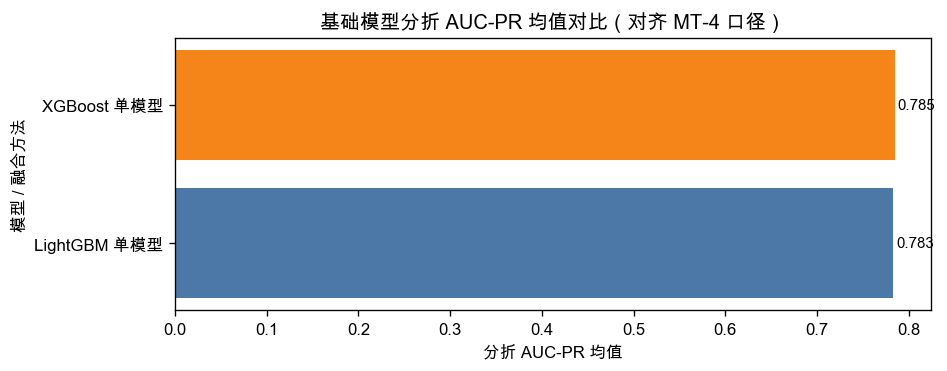

已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/基础模型_分折_AUC_PR_波动.png


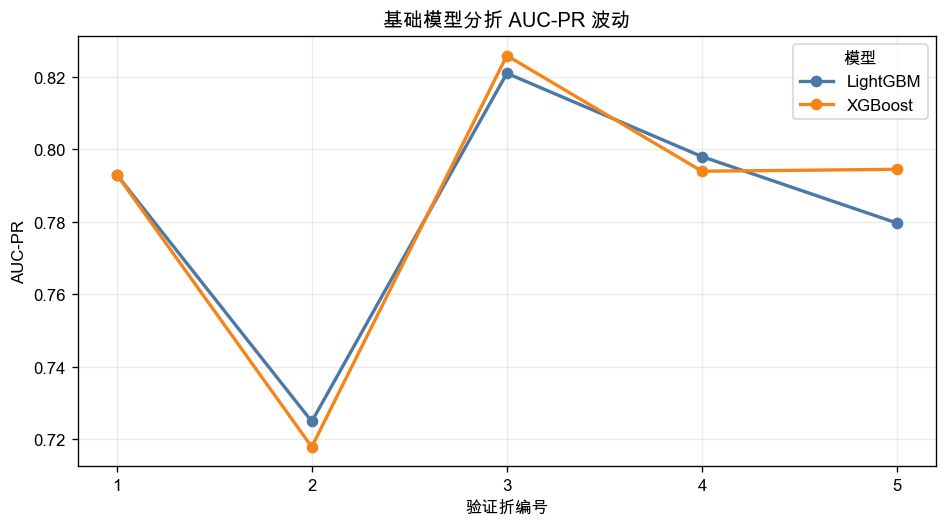

In [60]:
base_oof = {}
base_oof_covered = {}
base_fold_metrics = []
base_importance = []
base_eval_rows = []
base_threshold_scans = {}

for model_name, params in [('LightGBM', BEST_LGB_PARAMS), ('XGBoost', BEST_XGB_PARAMS)]:
    print(f'\n开始训练 {model_name} OOF 预测（使用 MT-4 最佳参数）...')
    oof, fold_metrics, importance_df, covered = cross_val_oof_with_importance(
        model_name,
        df_model,
        MODEL_FEATURES,
        params=params,
        n_splits=CV_N_SPLITS,
    )
    base_oof[model_name] = oof
    base_oof_covered[model_name] = covered
    base_fold_metrics.append(fold_metrics)
    base_importance.append(importance_df)
    row, scan = evaluate_prediction(model_name, df_model['Class'], oof)
    # 主口径对齐 MT-4：每折单独算 AUC-PR 后取均值；covered OOF 只是辅助整体口径。
    row.update({
        'AUC-PR_fold_mean': float(fold_metrics['AUC-PR'].mean()),
        'AUC-PR_fold_std': float(fold_metrics['AUC-PR'].std(ddof=0)),
        'logloss_fold_mean': float(fold_metrics['logloss'].mean()),
        'logloss_fold_std': float(fold_metrics['logloss'].std(ddof=0)),
    })
    base_eval_rows.append(row)
    base_threshold_scans[model_name] = scan

base_fold_metrics = pd.concat(base_fold_metrics, ignore_index=True)
base_importance = pd.concat(base_importance, ignore_index=True)
base_results = pd.DataFrame(base_eval_rows).sort_values('AUC-PR_fold_mean', ascending=False)

print('\n基础模型结果（主口径为分折 AUC-PR 均值；covered OOF 指标仅作辅助）')
display(base_results.round(4))
print('\n基础模型分折结果')
display(base_fold_metrics.round(5))

plot_metric_bar(
    base_results,
    metric='AUC-PR_fold_mean',
    title='基础模型分折 AUC-PR 均值对比（对齐 MT-4 口径）',
    filename='基础模型_分折AUC_PR均值_对比.png',
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for model_name, group in base_fold_metrics.groupby('model'):
    ax.plot(
        group['fold'],
        group['AUC-PR'],
        marker='o',
        linewidth=2,
        label=model_name,
        color=MODEL_COLORS.get(model_name),
    )
ax.set_title('基础模型分折 AUC-PR 波动')
ax.set_xlabel('验证折编号')
ax.set_ylabel('AUC-PR')
ax.set_xticks(sorted(base_fold_metrics['fold'].unique()))
ax.grid(alpha=0.25)
ax.legend(title='模型')
save_figure(fig, '基础模型_分折_AUC_PR_波动.png')
plt.show()

各模型 Top 特征贡献（按归一化贡献百分比从高到低排序）


,模型,特征,贡献百分比
0,LightGBM,V14,58.159
1,LightGBM,V10,8.796
2,LightGBM,V4,7.690
3,LightGBM,V12,5.971
4,LightGBM,V8,1.573
5,LightGBM,V17,1.486
6,LightGBM,V3,1.336
7,LightGBM,Amount,1.307
8,LightGBM,V20,1.155
9,LightGBM,V19,1.085


LightGBM 与 XGBoost 综合 Top 特征贡献（按平均贡献百分比从高到低排序）


model,特征,LightGBM 贡献百分比,XGBoost 贡献百分比,平均贡献百分比
0,V14,58.159,28.705,43.432
1,V10,8.796,15.371,12.084
2,V17,1.486,11.337,6.412
3,V12,5.971,4.774,5.373
4,V4,7.690,3.011,5.351
5,V11,0.743,4.187,2.465
6,one_euro_V4,0.073,3.361,1.717
7,V3,1.336,1.372,1.354
8,V19,1.085,1.544,1.314
9,one_euro_V14,0.230,2.334,1.282


特征贡献表已保存到: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output
已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/综合_Top20_特征贡献.png


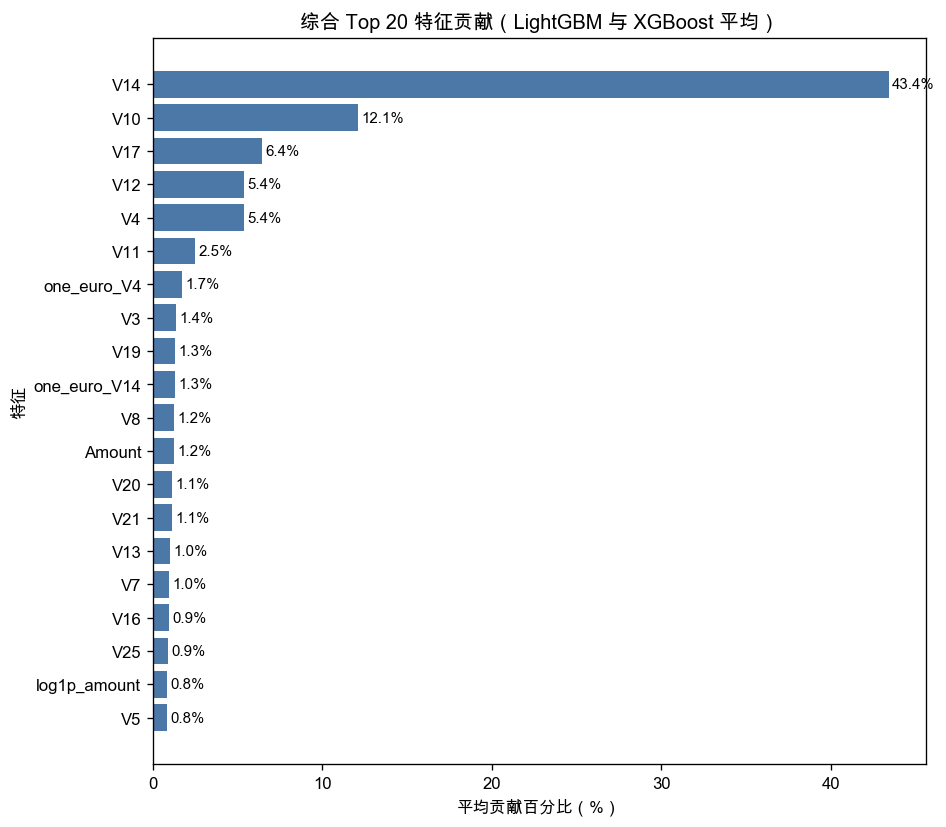

已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/基础模型_Top特征贡献对比.png


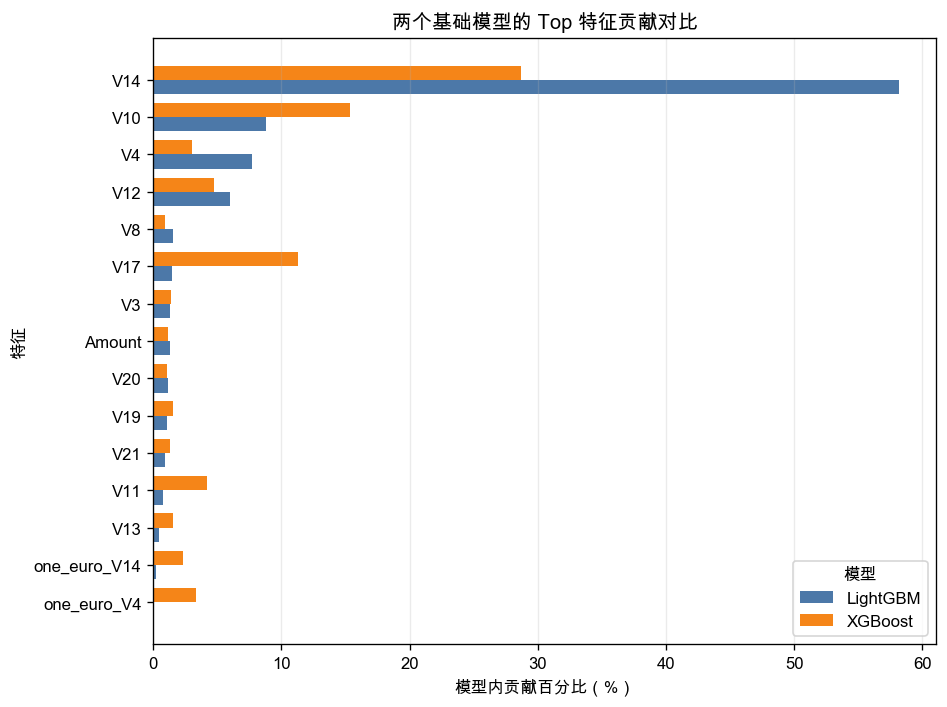

In [61]:
importance_summary = summarize_importance(base_importance)
importance_pivot = (
    importance_summary.pivot(index='feature', columns='model', values='importance_share')
    .fillna(0.0)
)
importance_pivot['mean_share'] = importance_pivot.mean(axis=1)
importance_pivot = importance_pivot.sort_values('mean_share', ascending=False)

print('各模型 Top 特征贡献（按归一化贡献百分比从高到低排序）')
# LightGBM / XGBoost 的原生 gain 绝对值量纲不同，且 LightGBM gain 往往很大。
# 因此表格只展示“模型内贡献百分比”，不展示原始 gain 大数，避免误读。
top_importance_table = (
    importance_summary.groupby('model')
    .head(20)
    .reset_index(drop=True)
    .assign(贡献百分比=lambda d: d['importance_share'] * 100)
    .rename(columns={'model': '模型', 'feature': '特征'})
)
top_importance_table = top_importance_table[['模型', '特征', '贡献百分比']]
display(display_readable_table(top_importance_table, precision=3))

print('LightGBM 与 XGBoost 综合 Top 特征贡献（按平均贡献百分比从高到低排序）')
top_combined_table = (
    importance_pivot.head(20)
    .reset_index()
    .rename(columns={'feature': '特征', 'mean_share': '平均贡献占比'})
)
for col in ['LightGBM', 'XGBoost', '平均贡献占比']:
    top_combined_table[col] = top_combined_table[col] * 100
top_combined_table = top_combined_table.rename(columns={
    'LightGBM': 'LightGBM 贡献百分比',
    'XGBoost': 'XGBoost 贡献百分比',
    '平均贡献占比': '平均贡献百分比',
})
display(display_readable_table(top_combined_table, precision=3))

importance_summary.to_csv(OUTPUT_DIR / 'feature_importance_by_model.csv', index=False)
importance_pivot.reset_index().to_csv(OUTPUT_DIR / 'feature_importance_combined.csv', index=False)
print('特征贡献表已保存到:', OUTPUT_DIR)

# 图 1：按两个模型平均贡献排序，查看最核心的特征。图中使用百分比，不展示原始 gain。
top_combined = importance_pivot.head(20).sort_values('mean_share', ascending=True)
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_combined.index, top_combined['mean_share'] * 100, color='#4C78A8')
ax.set_title('综合 Top 20 特征贡献（LightGBM 与 XGBoost 平均）')
ax.set_xlabel('平均贡献百分比（%）')
ax.set_ylabel('特征')
add_bar_labels(ax, fmt='{:.1f}%', padding=0.2)
save_figure(fig, '综合_Top20_特征贡献.png')
plt.show()

# 图 2：同一批 Top 特征下，对比两个模型的贡献差异。百分比已在各模型内部归一化。
compare_df = (importance_pivot.head(15)[['LightGBM', 'XGBoost']] * 100).sort_values('LightGBM')
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(compare_df))
bar_height = 0.38
ax.barh(y_pos - bar_height / 2, compare_df['LightGBM'], height=bar_height, label='LightGBM', color=MODEL_COLORS['LightGBM'])
ax.barh(y_pos + bar_height / 2, compare_df['XGBoost'], height=bar_height, label='XGBoost', color=MODEL_COLORS['XGBoost'])
ax.set_yticks(y_pos)
ax.set_yticklabels(compare_df.index)
ax.set_title('两个基础模型的 Top 特征贡献对比')
ax.set_xlabel('模型内贡献百分比（%）')
ax.set_ylabel('特征')
ax.legend(title='模型')
ax.grid(axis='x', alpha=0.25)
save_figure(fig, '基础模型_Top特征贡献对比.png')
plt.show()

In [62]:
# 可选：在抽样样本上计算 SHAP 贡献。
# 默认关闭，因为它会额外全量拟合模型并计算解释值；需要更细的样本级解释时再打开。
RUN_SHAP = False
SHAP_SAMPLE_SIZE = 5000

if RUN_SHAP:
    import shap

    shap_rows = []
    sample_idx = df_model.sample(
        n=min(SHAP_SAMPLE_SIZE, len(df_model)),
        random_state=CV_RANDOM_STATE,
        stratify=df_model['Class'] if df_model['Class'].nunique() == 2 else None,
    ).index
    X_sample = df_model.loc[sample_idx, MODEL_FEATURES]
    y_all = df_model['Class']

    for model_name, params in [('LightGBM', BEST_LGB_PARAMS), ('XGBoost', BEST_XGB_PARAMS)]:
        clf = make_classifier(model_name, y_all, params=params)
        fit_classifier(clf, model_name, df_model[MODEL_FEATURES], y_all)
        explainer = shap.TreeExplainer(clf)
        values = explainer.shap_values(X_sample)
        if isinstance(values, list):
            values = values[1]
        mean_abs = np.abs(values).mean(axis=0)
        shap_rows.append(pd.DataFrame({
            'model': model_name,
            'feature': MODEL_FEATURES,
            'mean_abs_shap': mean_abs,
        }))

    shap_summary = pd.concat(shap_rows, ignore_index=True).sort_values(['model', 'mean_abs_shap'], ascending=[True, False])
    display(shap_summary.groupby('model').head(20).round(6))
    shap_summary.to_csv(OUTPUT_DIR / 'shap_mean_abs_sample.csv', index=False)
else:
    print('已跳过 SHAP。若需要抽样 SHAP 贡献，请把 RUN_SHAP 改为 True 后重新运行本单元。')

已跳过 SHAP。若需要抽样 SHAP 贡献，请把 RUN_SHAP 改为 True 后重新运行本单元。


基础模型融合可评估样本数: 237,335 / 284,807
基础模型 OOF 预测相关性（只统计有效 OOF 样本）


,相关性类型,lgb_oof_vs_xgb_oof
0,Pearson 线性相关,0.9679
1,Spearman 排名相关,0.6944


已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/基础模型_OOF预测_Pearson相关系数.png


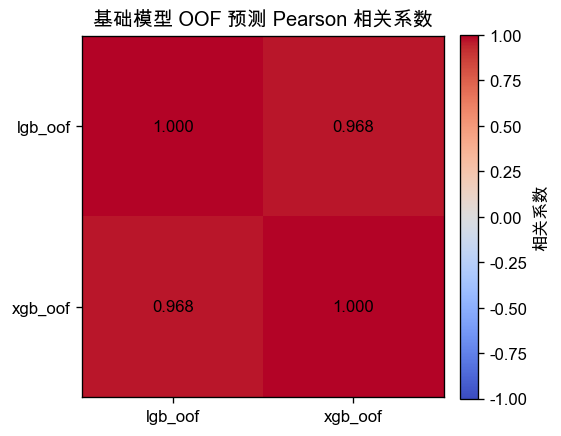

  Stacking 第 1/5 折跳过：训练或验证样本没有基础模型 OOF 预测
  Stacking 第 2/5 折完成（meta 训练样本=47,467，验证样本=47,467）
  Stacking 第 3/5 折完成（meta 训练样本=94,934，验证样本=47,467）
  Stacking 第 4/5 折完成（meta 训练样本=142,396，验证样本=47,467）
  Stacking 第 5/5 折完成（meta 训练样本=189,866，验证样本=47,467）
三种融合共同可评估样本数: 189,868 / 284,807
最优加权平均结果


,method,n_eval,n_excluded,AUC-PR,logloss,best_threshold,F1,Precision,Recall,FP,FN,w_lgb,w_xgb
22,weighted_average_best,189868,0,0.77393,0.00308,0.85,0.81452,0.91403,0.73455,19,73,0.22,0.78


权重搜索 Top 10 候选


,method,n_eval,n_excluded,AUC-PR,logloss,best_threshold,F1,Precision,Recall,FP,FN,w_lgb,w_xgb
22,weighted_average,189868,0,0.77393,0.00308,0.85,0.81452,0.91403,0.73455,19,73,0.22,0.78
21,weighted_average,189868,0,0.77392,0.00307,0.85,0.81452,0.91403,0.73455,19,73,0.21,0.79
23,weighted_average,189868,0,0.77386,0.00308,0.86,0.81452,0.91403,0.73455,19,73,0.23,0.77
19,weighted_average,189868,0,0.77385,0.00307,0.85,0.81452,0.91403,0.73455,19,73,0.19,0.81
20,weighted_average,189868,0,0.77385,0.00307,0.85,0.81452,0.91403,0.73455,19,73,0.20,0.80
18,weighted_average,189868,0,0.77382,0.00307,0.85,0.81452,0.91403,0.73455,19,73,0.18,0.82
17,weighted_average,189868,0,0.77380,0.00306,0.84,0.81452,0.91403,0.73455,19,73,0.17,0.83
16,weighted_average,189868,0,0.77371,0.00306,0.84,0.81452,0.91403,0.73455,19,73,0.16,0.84
14,weighted_average,189868,0,0.77366,0.00306,0.80,0.81600,0.90667,0.74182,21,71,0.14,0.86
15,weighted_average,189868,0,0.77365,0.00306,0.84,0.81452,0.91403,0.73455,19,73,0.15,0.85


已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/加权平均_LightGBM权重搜索曲线.png


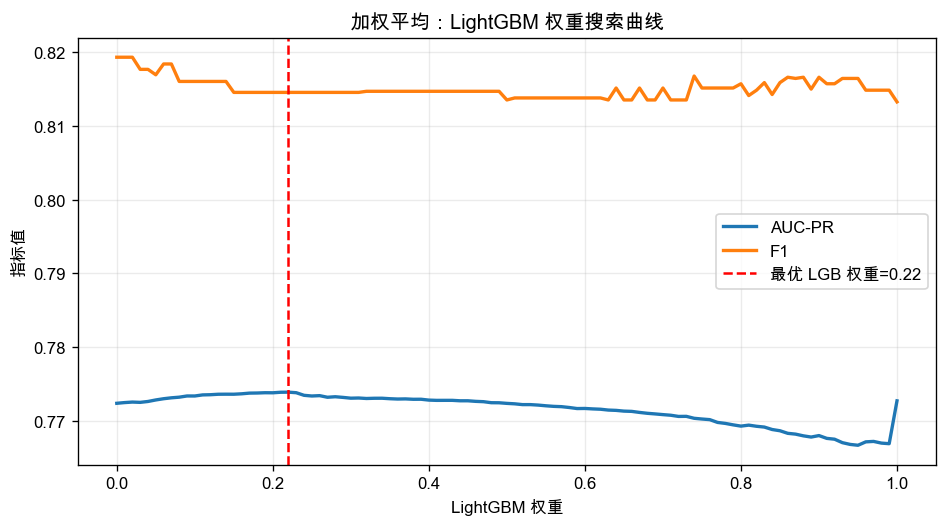

三种融合方案整体结果（共同有效 OOF 样本口径）


,method,n_eval,n_excluded,AUC-PR,logloss,best_threshold,F1,Precision,Recall,FP,FN,w_lgb,w_xgb
1,rank_average,189868,0,0.77980,0.91551,0.99,0.31096,0.19024,0.85091,996,41,NaN,NaN
0,weighted_average_best,189868,0,0.77393,0.00308,0.85,0.81452,0.91403,0.73455,19,73,0.22,0.78
2,logistic_stacking,189868,0,0.67708,0.17137,0.99,0.67781,0.58225,0.81091,160,52,NaN,NaN


已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/融合方案_AUC_PR_对比.png


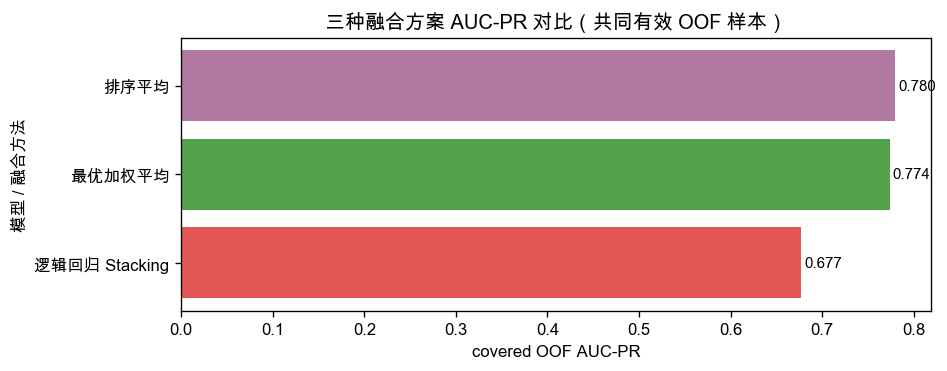

已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/融合方案_F1_对比.png


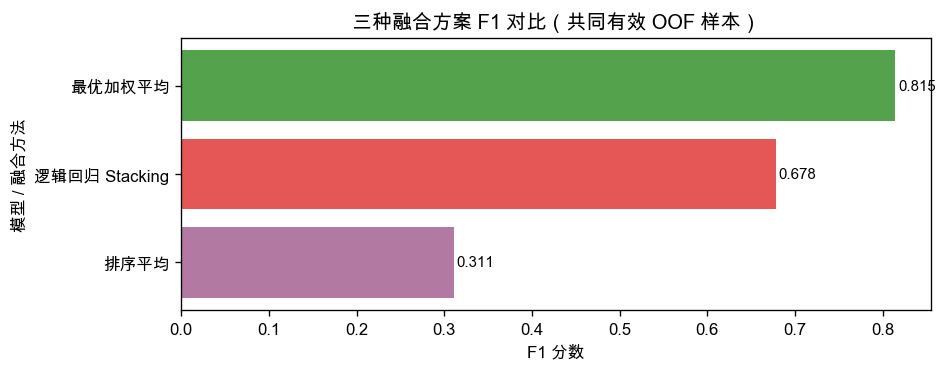

已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/融合方案_核心指标对比.png


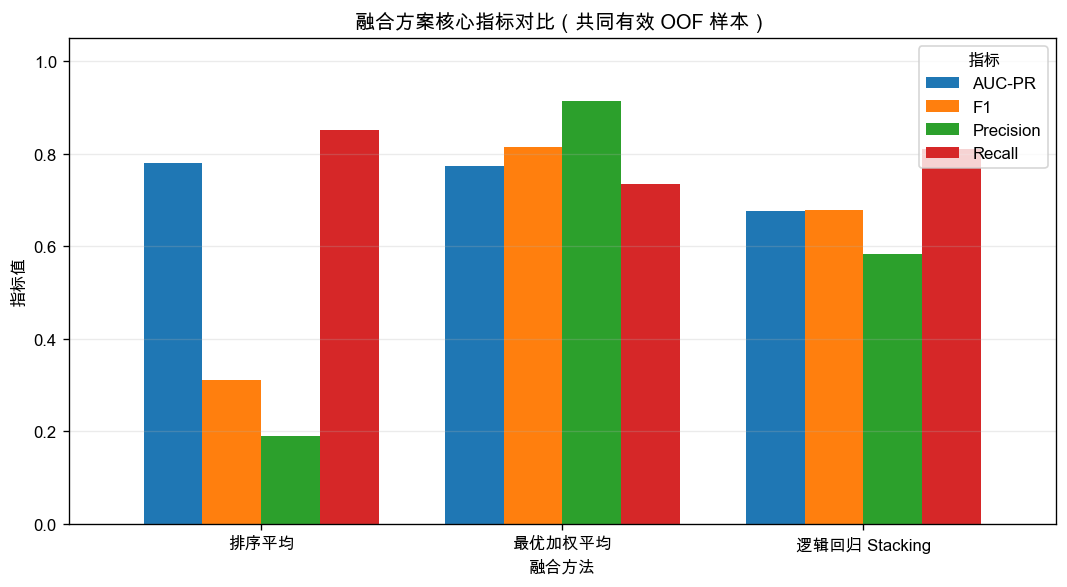

已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/最优融合方案_阈值扫描曲线.png


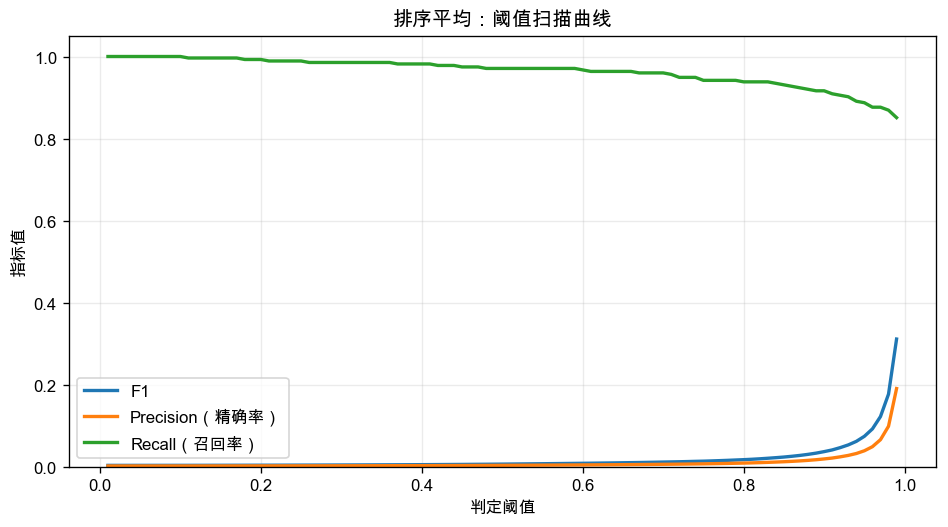

Stacking 二层模型系数


,meta_feature,coef_mean,coef_std
0,lgb_oof,0.00334,0.00074
1,xgb_oof,0.01069,0.00872


已保存图表: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures/Stacking_二层模型系数.png


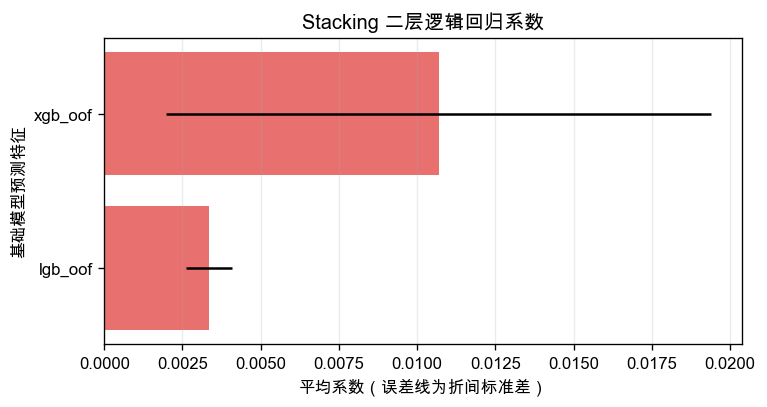

In [63]:
y_true = df_model['Class'].to_numpy()
lgb_oof = base_oof['LightGBM']
xgb_oof = base_oof['XGBoost']

# 基础模型的有效 OOF 样本：两个模型都在验证折里真正产生过预测。
# walk-forward 最前面的 warm-up 样本没有预测，因此保持 NaN 并排除。
base_fusion_mask = np.isfinite(lgb_oof) & np.isfinite(xgb_oof)
print(f'基础模型融合可评估样本数: {base_fusion_mask.sum():,} / {len(base_fusion_mask):,}')

# 先训练 stacking 的二层 OOF。严格使用 OOF 特征时，最早的 meta fold 可能没有可用训练样本，会被跳过。
meta_features = pd.DataFrame({
    'lgb_oof': lgb_oof,
    'xgb_oof': xgb_oof,
})

# 相关性只在两个基础模型都有真实 OOF 预测的样本上计算；warm-up 样本仍然排除。
meta_corr_input = meta_features.loc[base_fusion_mask]
pearson_corr = meta_corr_input.corr(method='pearson')
spearman_corr = meta_corr_input.corr(method='spearman')
correlation_summary = pd.DataFrame({
    '相关性类型': ['Pearson 线性相关', 'Spearman 排名相关'],
    'lgb_oof_vs_xgb_oof': [
        pearson_corr.loc['lgb_oof', 'xgb_oof'],
        spearman_corr.loc['lgb_oof', 'xgb_oof'],
    ],
})
print('基础模型 OOF 预测相关性（只统计有效 OOF 样本）')
display(display_readable_table(correlation_summary, precision=4))

fig, ax = plt.subplots(figsize=(4.5, 3.8))
im = ax.imshow(pearson_corr.values, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(pearson_corr.columns)))
ax.set_yticks(range(len(pearson_corr.index)))
ax.set_xticklabels(pearson_corr.columns)
ax.set_yticklabels(pearson_corr.index)
ax.set_title('基础模型 OOF 预测 Pearson 相关系数')
for i in range(pearson_corr.shape[0]):
    for j in range(pearson_corr.shape[1]):
        ax.text(j, i, f'{pearson_corr.iloc[i, j]:.3f}', ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='相关系数')
save_figure(fig, '基础模型_OOF预测_Pearson相关系数.png')
plt.show()

stack_oof, stack_coef = stacking_oof(meta_features, y_true, n_splits=CV_N_SPLITS)

# 为了让三种融合方案公平比较，统一在三者都有有效预测的样本上评估。
# 如果只比较加权平均和 rank average，可以把这里换成 base_fusion_mask。
fusion_common_mask = base_fusion_mask & np.isfinite(stack_oof)
print(f'三种融合共同可评估样本数: {fusion_common_mask.sum():,} / {len(fusion_common_mask):,}')

fusion_y = y_true[fusion_common_mask]
fusion_lgb = lgb_oof[fusion_common_mask]
fusion_xgb = xgb_oof[fusion_common_mask]
fusion_stack = stack_oof[fusion_common_mask]

fusion_rows = []
fusion_scans = {}

# 方案 1：权重搜索平均。这里扫描 0.00 到 1.00 的 LightGBM 权重，XGBoost 权重为 1 - w。
best_weighted, weighted_grid, weighted_scan = weighted_average_search(fusion_y, fusion_lgb, fusion_xgb)
best_weighted['method'] = 'weighted_average_best'
fusion_rows.append(best_weighted.to_dict())
fusion_scans['weighted_average_best'] = weighted_scan

print('最优加权平均结果')
display(pd.DataFrame([best_weighted]).round(5))
print('权重搜索 Top 10 候选')
display(weighted_grid.sort_values(['AUC-PR', 'F1', 'logloss'], ascending=[False, False, True]).head(10).round(5))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(weighted_grid['w_lgb'], weighted_grid['AUC-PR'], label='AUC-PR', linewidth=2)
ax.plot(weighted_grid['w_lgb'], weighted_grid['F1'], label='F1', linewidth=2)
ax.axvline(best_weighted['w_lgb'], color='red', linestyle='--', label=f"最优 LGB 权重={best_weighted['w_lgb']:.2f}")
ax.set_title('加权平均：LightGBM 权重搜索曲线')
ax.set_xlabel('LightGBM 权重')
ax.set_ylabel('指标值')
ax.grid(alpha=0.25)
ax.legend()
save_figure(fig, '加权平均_LightGBM权重搜索曲线.png')
plt.show()

# 方案 2：Rank average。先转成百分位排名再平均，适合两个模型概率尺度不完全一致的情况。
rank_avg_proba = 0.5 * rank_percentile(fusion_lgb) + 0.5 * rank_percentile(fusion_xgb)
rank_row, rank_scan = evaluate_prediction('rank_average', fusion_y, rank_avg_proba)
fusion_rows.append(rank_row)
fusion_scans['rank_average'] = rank_scan

# 方案 3：Logistic Regression stacking。这里直接评估二层模型在共同样本上的 OOF 预测。
stack_row, stack_scan = evaluate_prediction('logistic_stacking', fusion_y, fusion_stack)
fusion_rows.append(stack_row)
fusion_scans['logistic_stacking'] = stack_scan

fusion_results = pd.DataFrame(fusion_rows).sort_values(['AUC-PR', 'F1', 'logloss'], ascending=[False, False, True])

print('三种融合方案整体结果（共同有效 OOF 样本口径）')
display(fusion_results.round(5))

plot_metric_bar(
    fusion_results,
    metric='AUC-PR',
    title='三种融合方案 AUC-PR 对比（共同有效 OOF 样本）',
    filename='融合方案_AUC_PR_对比.png',
)
plot_metric_bar(
    fusion_results,
    metric='F1',
    title='三种融合方案 F1 对比（共同有效 OOF 样本）',
    filename='融合方案_F1_对比.png',
)

metric_compare = fusion_results.copy()
metric_compare['方法'] = metric_compare['method'].map(method_name_zh)
metric_compare = metric_compare.set_index('方法')[['AUC-PR', 'F1', 'Precision', 'Recall']]
fig, ax = plt.subplots(figsize=(9, 5))
metric_compare.plot(kind='bar', ax=ax, width=0.78)
ax.set_title('融合方案核心指标对比（共同有效 OOF 样本）')
ax.set_xlabel('融合方法')
ax.set_ylabel('指标值')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.25)
ax.legend(title='指标')
save_figure(fig, '融合方案_核心指标对比.png')
plt.show()

best_fusion_method = fusion_results.iloc[0]['method']
plot_threshold_scan(
    fusion_scans[best_fusion_method],
    title=f'{method_name_zh(best_fusion_method)}：阈值扫描曲线',
    filename='最优融合方案_阈值扫描曲线.png',
)

print('Stacking 二层模型系数')
stack_coef_summary = stack_coef.groupby('meta_feature', as_index=False).agg(coef_mean=('coef', 'mean'), coef_std=('coef', 'std'))
display(stack_coef_summary.round(5))

fig, ax = plt.subplots(figsize=(6.5, 3.5))
coef_plot = stack_coef_summary.sort_values('coef_mean')
ax.barh(coef_plot['meta_feature'], coef_plot['coef_mean'], xerr=coef_plot['coef_std'], color='#E45756', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Stacking 二层逻辑回归系数')
ax.set_xlabel('平均系数（误差线为折间标准差）')
ax.set_ylabel('基础模型预测特征')
ax.grid(axis='x', alpha=0.25)
save_figure(fig, 'Stacking_二层模型系数.png')
plt.show()

In [64]:
base_results.to_csv(OUTPUT_DIR / 'base_model_oof_results.csv', index=False)
base_fold_metrics.to_csv(OUTPUT_DIR / 'base_model_fold_metrics.csv', index=False)
weighted_grid.to_csv(OUTPUT_DIR / 'weighted_average_grid.csv', index=False)
fusion_results.to_csv(OUTPUT_DIR / 'fusion_results.csv', index=False)
stack_coef.to_csv(OUTPUT_DIR / 'stacking_meta_coefficients.csv', index=False)

for name, scan in fusion_scans.items():
    scan.to_csv(OUTPUT_DIR / f'{name}_threshold_scan.csv', index=False)

figure_files = sorted(str(p.relative_to(PROJECT_ROOT)) for p in FIGURE_DIR.glob('*.png'))
summary = {
    '来源配置': str(MT4_CONFIG_PATH),
    '特征数量': len(MODEL_FEATURES),
    '特征清单': MODEL_FEATURES,
    'LightGBM 最佳参数': BEST_LGB_PARAMS,
    'XGBoost 最佳参数': BEST_XGB_PARAMS,
    '融合结果': fusion_results.to_dict(orient='records'),
    '图表文件': figure_files,
}
with open(OUTPUT_DIR / 'model_stacking_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('表格和汇总文件已保存到:', OUTPUT_DIR)
print('图表文件已保存到:', FIGURE_DIR)
display(fusion_results.round(5))
display(pd.DataFrame({'图表文件': figure_files}))

表格和汇总文件已保存到: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output
图表文件已保存到: /Users/jingyuhe/Desktop/credit-fraud-dealing-with-imbalanced-datasets/src/model-stacking/output/figures


,method,n_eval,n_excluded,AUC-PR,logloss,best_threshold,F1,Precision,Recall,FP,FN,w_lgb,w_xgb
1,rank_average,189868,0,0.77980,0.91551,0.99,0.31096,0.19024,0.85091,996,41,NaN,NaN
0,weighted_average_best,189868,0,0.77393,0.00308,0.85,0.81452,0.91403,0.73455,19,73,0.22,0.78
2,logistic_stacking,189868,0,0.67708,0.17137,0.99,0.67781,0.58225,0.81091,160,52,NaN,NaN


,图表文件
0,src/model-stacking/output/figures/Stacking_二层模...
1,src/model-stacking/output/figures/加权平均_LightGB...
2,src/model-stacking/output/figures/基础模型_OOF_AUC...
3,src/model-stacking/output/figures/基础模型_OOF预测_P...
4,src/model-stacking/output/figures/基础模型_Top特征贡献...
5,src/model-stacking/output/figures/基础模型_分折AUC_P...
6,src/model-stacking/output/figures/基础模型_分折_AUC_...
7,src/model-stacking/output/figures/最优融合方案_阈值扫描曲...
8,src/model-stacking/output/figures/综合_Top20_特征贡...
9,src/model-stacking/output/figures/融合方案_AUC_PR_...


## 阅读结果时的建议

### 1. 先看特征贡献

优先看 `综合_Top20_特征贡献.png` 和 `基础模型_Top特征贡献对比.png`。如果某个特征在 LightGBM 和 XGBoost 中都靠前，说明它对当前任务比较稳定；如果只在某一个模型中异常靠前，需要进一步检查是否存在偶然相关、时间泄漏或分布漂移。

### 2. 再看融合效果

优先看 `fusion_results` 的 AUC-PR，其次看 F1 最优阈值下的 Precision / Recall / FP / FN。信用卡欺诈样本极少，AUC-PR 比 ROC-AUC 更贴近真实检出能力。

注意：walk-forward 的最前段样本只作为 warm-up 训练窗口，不会进入验证折，因此没有 OOF 预测。代码里用 `NaN` 标记这部分样本，并在评估时排除；结果表中的 `n_excluded` 就是这类未参与 OOF 评估的样本数。

### 3. 怎么选融合方案

如果最优加权平均和 stacking 的 AUC-PR 差距很小，优先选择加权平均，因为它更简单、更稳、更容易解释。如果 stacking 明显提升，并且二层系数在各折中方向稳定，再考虑使用 stacking。

### 4. 看阈值曲线

`最优融合方案_阈值扫描曲线.png` 展示阈值变化时 F1、精确率、召回率如何变化。如果业务更怕误报，就选精确率更高的阈值；如果业务更怕漏报，就选召回率更高的阈值。